In [27]:
import pandas as pd
from scipy import stats

data = {
    'Producto': ['A', 'B', 'C', 'D', 'A', 'B', 'C', 'D', 'A', 'B'],
    'Ventas': [200, 150, 250, 300, 230, 190, 270, 320, 210, 180],
    'Precio': [15.5, 20.0, 22.5, 30.0, 15.5, 20.0, 22.5, 30.0, 15.5, 20.0]
}

df = pd.DataFrame(data)

print(df)


data_atipico = {
    'Producto': ['A', 'B', 'C', 'D', 'A', 'B', 'C', 'D', 'A', 'B','C','D'],
    'Ventas': [200, 150, 250, 300, 230, 190, 270, 320, 210, 180,1800,20],
    'Precio': [15.5, 20.0, 22.5, 30.0, 15.5, 20.0, 22.5, 30.0, 15.5, 20.0,200.0,10]
}


df_atipico = pd.DataFrame(data_atipico)

print(df_atipico)


  Producto  Ventas  Precio
0        A     200    15.5
1        B     150    20.0
2        C     250    22.5
3        D     300    30.0
4        A     230    15.5
5        B     190    20.0
6        C     270    22.5
7        D     320    30.0
8        A     210    15.5
9        B     180    20.0
   Producto  Ventas  Precio
0         A     200    15.5
1         B     150    20.0
2         C     250    22.5
3         D     300    30.0
4         A     230    15.5
5         B     190    20.0
6         C     270    22.5
7         D     320    30.0
8         A     210    15.5
9         B     180    20.0
10        C    1800   200.0
11        D      20    10.0


## analizar valores

In [28]:
df.describe()

,Ventas,Precio
count,10.000000,10.000000
mean,230.000000,21.150000
std,54.569018,5.375097
min,150.000000,15.500000
25%,192.500000,16.625000
50%,220.000000,20.000000
75%,265.000000,22.500000
max,320.000000,30.000000


### Matriz Correlacion



In [29]:
correlacion_Ventas_Precio=df[["Ventas","Precio"]].corr()
print(correlacion_Ventas_Precio)

          Ventas    Precio
Ventas  1.000000  0.748156
Precio  0.748156  1.000000


# quartiles



In [30]:
q1=df["Ventas"].quantile(0.25)
q3=df["Ventas"].quantile(0.75)

iqr=q3-q1
print(iqr)

72.5


# Limites, para descartar valores atipicos

In [31]:
limite_superior=q3+1.5*iqr
limite_inferior=q1-1.5*iqr

print("\nsin valores atipicos\n")
print(len(df))

# filtrar atipicos
df_filtrado = df.loc[(df["Ventas"] > limite_inferior) & (df["Ventas"] < limite_superior)]
# detectar atipicos
df_outliers = df[(df["Ventas"] < limite_inferior) | (df["Ventas"] > limite_superior)]


print(len(df_filtrado))




sin valores atipicos

10
10


In [32]:

print("\nCon valores atipicos\n")
q1_atipico=df_atipico["Ventas"].quantile(0.25)
q3_atipico=df_atipico["Ventas"].quantile(0.75)

iqr_atip=q3_atipico-q1_atipico
print(iqr_atip)

atip_limite_superior=q3_atipico+1.5*iqr_atip
atip_limite_inferior=q1_atipico-1.5*iqr_atip


print(len(df_atipico))
df_filtrado=df_atipico.loc[(df["Ventas"] > atip_limite_inferior) & (df_atipico["Ventas"] < atip_limite_superior)]
# detectar outliers
# df_outliers = df[(df["Ventas"] < limite_inferior) | (df["Ventas"] > limite_superior)]

print(len(df_filtrado))





Con valores atipicos

90.0
12
10


# Z score Puntuación Z (Z-Score)
valores en funcion de la desviacion estandart

In [ ]:
z_scores=stats.zscore(df_atipico["Ventas"])
df_atipico["Ventas Zscore"]=z_scores
print(df)

## detectar atipicos
outliers_df_Ventas=df_atipico[(z_scores>2)|(z_scores<-2)]

print(outliers_df_Ventas)




  Producto  Ventas  Precio
0        A     200    15.5
1        B     150    20.0
2        C     250    22.5
3        D     300    30.0
4        A     230    15.5
5        B     190    20.0
6        C     270    22.5
7        D     320    30.0
8        A     210    15.5
9        B     180    20.0
   Producto  Ventas  Precio  Ventas Zscore
10        C    1800   200.0       3.269718


## graficar valores atipicos

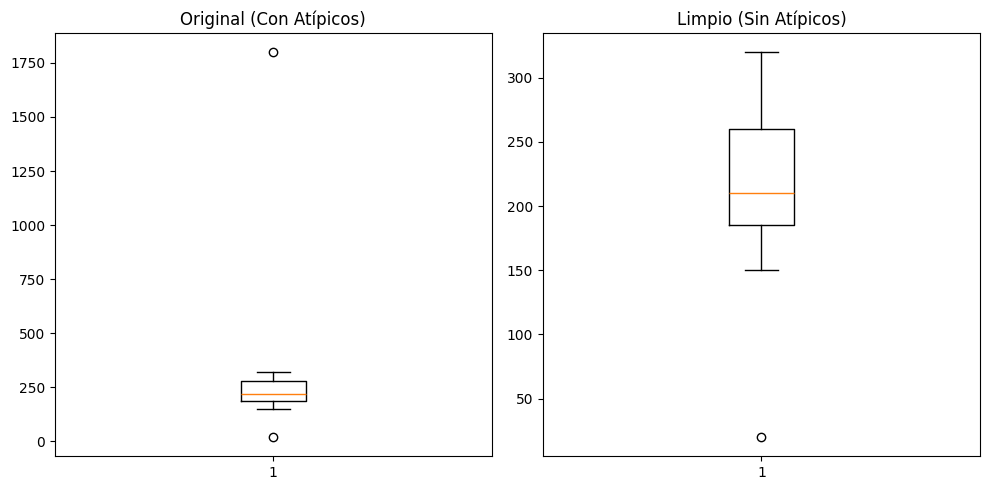

In [ ]:
import numpy as np
import matplotlib.pyplot as plt # Corregido el alias estándar

# 1. Creamos una columna nueva para comparar los datos "limpios"
# np.where(condición, valor_si_cumple, valor_si_no_cumple)
# se puede reemplazar con el promedio tambien 
df_atipico["Ventas_Sin_Atipicos"] = np.where((z_scores > 2) | (z_scores < -2), np.nan, df_atipico["Ventas"])

# 2. Graficamos ambos para comparar
plt.figure(figsize=(10, 5))

# Boxplot de los datos originales (con outliers)
plt.subplot(1, 2, 1)
plt.boxplot(df_atipico["Ventas"].dropna())
plt.title("Original (Con Atípicos)")

# Boxplot de los datos filtrados (sin outliers)
plt.subplot(1, 2, 2)
plt.boxplot(df_atipico["Ventas_Sin_Atipicos"].dropna())
plt.title("Limpio (Sin Atípicos)")

plt.tight_layout()
plt.show()

